# Product and Item Exploratory Data Analysis
## Notebook purpose

This notebook explores product-level and item-level patterns related to returned orders.

# Import Important Libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
DATA_DIR = PROJECT_ROOT / "data"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")

Project root: C:\Users\Victus\OneDrive\Desktop\E-Commerce-Sales-Analytics
Data directory: C:\Users\Victus\OneDrive\Desktop\E-Commerce-Sales-Analytics\data


# Load And Prepare Product, Item, And Return Data

In [ ]:
order_items_df = pd.read_csv(DATA_DIR / "order_items.csv")
products_df = pd.read_csv(DATA_DIR / "product_catalog.csv")
orders_return_df = pd.read_csv(
    DATA_DIR / "ecommerce_sales_customer_analytics_150k.csv",
    usecols=["order_id", "return_status"]
)

orders_return_df["return_label"] = (
    orders_return_df["return_status"] == "Returned"
).astype(int)

items_products_df = order_items_df.merge(
    products_df,
    on="product_id",
    how="left",
    validate="m:1",
    suffixes=("_item", "_catalog"),
    indicator="product_match"
)

item_analysis_df = items_products_df.merge(
    orders_return_df,
    on="order_id",
    how="left",
    validate="m:1",
    indicator="order_match"
)

print(f"Order-item rows: {len(order_items_df):,}")
print(f"Rows after product join: {len(items_products_df):,}")
print(f"Rows after return-label join: {len(item_analysis_df):,}")

Order-item rows: 397,569
Rows after product join: 397,569
Rows after return-label join: 397,569


In [15]:
items_products_df.head(5)

,order_id,product_id,quantity,unit_price_item,discount_percentage,discount_amount,gross_sales,tax_amount,shipping_cost,net_sales,product_cost_item,profit,product_name,product_category,product_subcategory,brand,supplier,unit_price_catalog,product_cost_catalog,product_rating,product_match
0,ORD-301242,PROD-000738,2,244.40,0.34,166.00,488.80,22.60,6.48,351.88,173.28,172.12,Garmin Total client-driven task-force Medical ...,Health & Wellness,Medical Devices,Garmin,Euro Logistics,244.40,86.64,4.80,both
1,ORD-301242,PROD-000181,3,287.13,0.36,311.89,861.39,38.47,5.55,593.52,415.05,172.92,Tommy Hilfiger Open-architected full-range foc...,Fashion,Shoes,Tommy Hilfiger,Pacific Trade,287.13,138.35,3.00,both
2,ORD-773460,PROD-000973,4,754.80,0.47,"1,413.89","3,019.20",305.01,9.00,"1,919.32","1,976.16",-65.84,Swarovski Re-engineered discrete monitoring Ea...,Jewelry,Earrings,Swarovski,MultiSource,754.80,494.04,3.50,both
3,ORD-773460,PROD-000268,4,31.36,0.34,42.17,125.44,15.82,0.00,99.09,55.72,43.37,NARS Enterprise-wide actuating firmware Fragra...,Beauty & Personal Care,Fragrances,NARS,Global Trade,31.36,13.93,4.00,both
4,ORD-449374,PROD-001040,3,6.31,0.09,1.70,18.93,1.21,0.98,19.42,5.91,12.53,Mars Multi-tiered homogeneous artificial intel...,Grocery,Pantry Staples,Mars,Asian Manufacturing,6.31,1.97,3.00,both


# Validate Joins And Build Product-Order Analysis Table

In [ ]:
join_summary = pd.Series({
    "item_rows": len(order_items_df),
    "unique_orders_in_items": order_items_df["order_id"].nunique(),
    "unique_products_in_items": order_items_df["product_id"].nunique(),
    "items_without_product_match": (
        item_analysis_df["product_match"] == "left_only"
    ).sum(),
    "items_without_order_match": (
        item_analysis_df["order_match"] == "left_only"
    ).sum(),
    "overall_order_return_rate_percent": round(
        orders_return_df["return_label"].mean() * 100, 2
    )
})

display(join_summary)
item_analysis_df = item_analysis_df[
    (item_analysis_df["product_match"] == "both") &
    (item_analysis_df["order_match"] == "both")
].copy()


product_order_df = (
    item_analysis_df
    .groupby(["order_id", "product_id"], as_index=False)
    .agg(
        return_label=("return_label", "first"),
        product_name=("product_name", "first"),
        product_category=("product_category", "first"),
        product_subcategory=("product_subcategory", "first"),
        brand=("brand", "first"),
        supplier=("supplier", "first"),
        product_rating=("product_rating", "first"),
        catalog_unit_price=("unit_price_catalog", "first"),
        total_quantity=("quantity", "sum"),
        average_item_price=("unit_price_item", "mean"),
        average_discount_percentage=("discount_percentage", "mean"),
        total_discount_amount=("discount_amount", "sum"),
        total_item_net_sales=("net_sales", "sum"),
        total_item_profit=("profit", "sum")
    )
)

print(f"Product-order rows: {len(product_order_df):,}")
print(f"Unique orders represented: {product_order_df['order_id'].nunique():,}")
display(product_order_df.head())

item_rows                           397,569.00
unique_orders_in_items              138,116.00
unique_products_in_items              1,175.00
items_without_product_match               0.00
items_without_order_match                 0.00
overall_order_return_rate_percent         6.85
dtype: float64

Product-order rows: 397,482
Unique orders represented: 138,116


,order_id,product_id,return_label,product_name,product_category,product_subcategory,brand,supplier,product_rating,catalog_unit_price,total_quantity,average_item_price,average_discount_percentage,total_discount_amount,total_item_net_sales,total_item_profit
0,ORD-100002,PROD-000132,0,Whirlpool Intuitive empowering database Coffee...,Home Appliances,Coffee Makers,Whirlpool,Global Trade,4.70,643.49,1,643.49,0.00,0.00,707.41,363.44
1,ORD-100002,PROD-000730,0,Philips Organized grid-enabled algorithm Medic...,Health & Wellness,Medical Devices,Philips,Domestic Producers,4.10,233.33,4,233.33,0.00,0.00,985.27,469.35
2,ORD-100004,PROD-000475,0,McGraw-Hill Innovative dedicated info-mediarie...,Books & Media,Fiction,McGraw-Hill,Asian Manufacturing,4.90,12.91,1,12.91,0.09,1.22,23.89,9.53
3,ORD-100004,PROD-000782,0,Garmin Open-architected value-added intranet B...,Health & Wellness,Blood Pressure Monitors,Garmin,Direct Import,4.10,116.11,1,116.11,0.10,11.49,125.75,55.48
4,ORD-100004,PROD-000912,0,Evenflo Innovative optimizing Graphical User I...,Baby & Kids,Clothing,Evenflo,Global Trade,4.40,335.86,1,335.86,0.04,14.11,383.73,183.92


# Overall Product And Item Summary

In [6]:
product_item_summary = pd.Series({
    "total_item_rows": len(item_analysis_df),
    "total_product_order_rows": len(product_order_df),
    "unique_orders": product_order_df["order_id"].nunique(),
    "unique_products": product_order_df["product_id"].nunique(),
    "average_products_per_order": round(
        len(product_order_df) / product_order_df["order_id"].nunique(), 2
    ),
    "average_quantity_per_product_order": round(
        product_order_df["total_quantity"].mean(), 2
    ),
    "average_product_rating": round(
        product_order_df["product_rating"].mean(), 2
    ),
    "item_weighted_return_rate_percent": round(
        product_order_df["return_label"].mean() * 100, 2
    )
})

display(product_item_summary)

total_item_rows                      397,569.00
total_product_order_rows             397,482.00
unique_orders                        138,116.00
unique_products                        1,175.00
average_products_per_order                 2.88
average_quantity_per_product_order         2.12
average_product_rating                     3.68
item_weighted_return_rate_percent          6.84
dtype: float64

# Helper Function For Return-Rate Analysis

In [7]:
def create_product_return_summary(
    dataframe,
    group_column,
    min_orders=1
):
    summary_data = (
        dataframe[["order_id", group_column, "return_label"]]
        .dropna(subset=[group_column])
        .drop_duplicates(subset=["order_id", group_column])
    )

    summary = (
        summary_data
        .groupby(group_column, as_index=False)
        .agg(
            total_orders=("order_id", "nunique"),
            returned_orders=("return_label", "sum"),
            return_rate=("return_label", "mean")
        )
    )

    summary["return_rate_percent"] = (
        summary["return_rate"] * 100
    ).round(2)

    return (
        summary[summary["total_orders"] >= min_orders]
        .sort_values(
            ["return_rate_percent", "total_orders"],
            ascending=[False, False]
        )
    )


overall_return_rate = orders_return_df["return_label"].mean() * 100

In [16]:
overall_return_rate

np.float64(6.850763126647166)

# Return Rate By Product Category

,product_category,total_orders,returned_orders,return_rate,return_rate_percent
0,Automotive,25103,1811,0.07,7.21
10,Jewelry,21578,1520,0.07,7.04
7,Health & Wellness,26468,1859,0.07,7.02
8,Home & Kitchen,21744,1517,0.07,6.98
4,Electronics,24235,1684,0.07,6.95
13,Sports & Outdoors,27700,1921,0.07,6.94
9,Home Appliances,24241,1673,0.07,6.90
6,Grocery,24177,1662,0.07,6.87
12,Pet Supplies,23020,1576,0.07,6.85
3,Books & Media,26758,1830,0.07,6.84


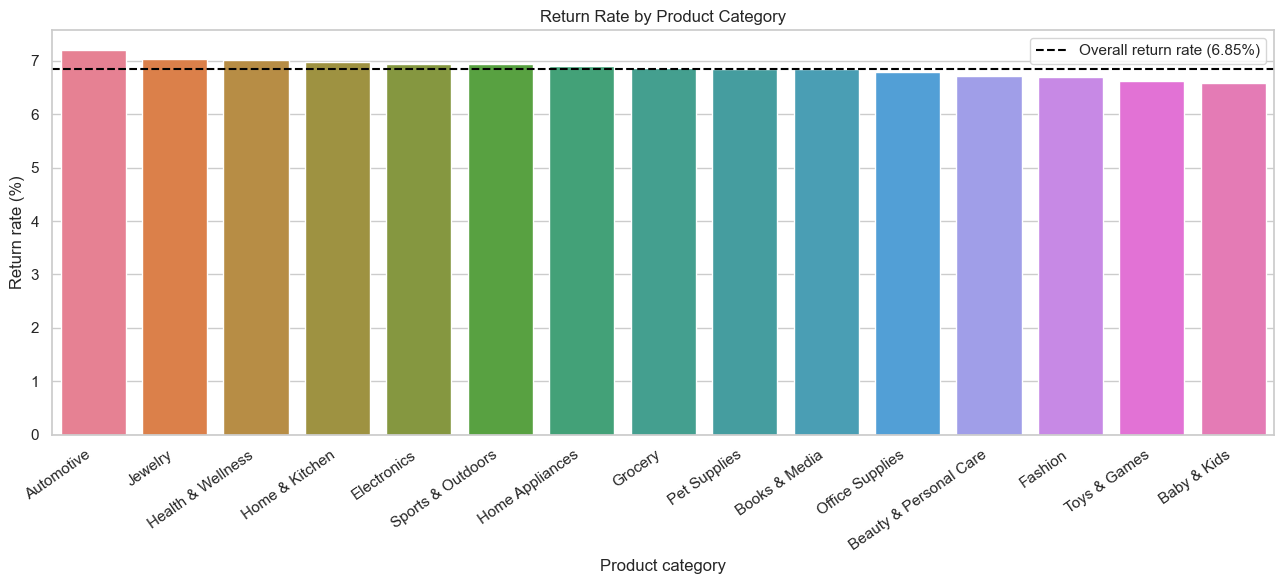

In [8]:
category_summary = create_product_return_summary(
    product_order_df,
    "product_category"
)

display(category_summary)

plt.figure(figsize=(13, 6))

sns.barplot(
    data=category_summary,
    x="product_category",
    y="return_rate_percent",
    hue="product_category",
    legend=False
)

plt.axhline(
    overall_return_rate,
    linestyle="--",
    color="black",
    label=f"Overall return rate ({overall_return_rate:.2f}%)"
)

plt.title("Return Rate by Product Category")
plt.xlabel("Product category")
plt.ylabel("Return rate (%)")
plt.xticks(rotation=35, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

# Return Rate By Product Subcategory

,product_subcategory,total_orders,returned_orders,return_rate,return_rate_percent
81,Pendants,2323,187,0.08,8.05
12,Batteries,3654,286,0.08,7.83
69,Motorcycle Gear,2704,211,0.08,7.80
82,Pet Beds,1685,130,0.08,7.72
96,Snacks,1683,130,0.08,7.72
53,Headphones,2747,211,0.08,7.68
51,Grooming,3029,232,0.08,7.66
58,Laptops,2358,180,0.08,7.63
59,Lighting,2060,157,0.08,7.62
47,Frozen Foods,5095,383,0.08,7.52


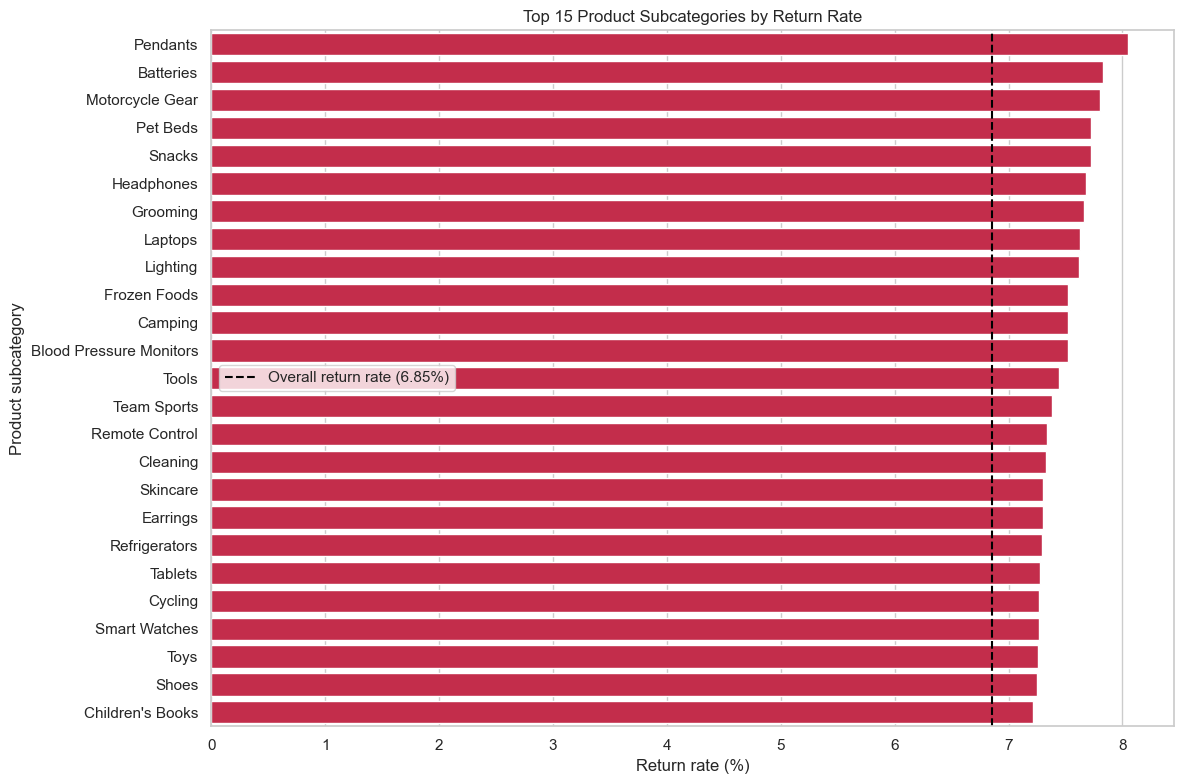

In [19]:
subcategory_summary = create_product_return_summary(
    product_order_df,
    "product_subcategory",
    min_orders=100
)

top_subcategories = subcategory_summary.head(25)

display(top_subcategories)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_subcategories,
    y="product_subcategory",
    x="return_rate_percent",
    color="crimson"
)

plt.axvline(
    overall_return_rate,
    linestyle="--",
    color="black",
    label=f"Overall return rate ({overall_return_rate:.2f}%)"
)

plt.title("Top 15 Product Subcategories by Return Rate")
plt.xlabel("Return rate (%)")
plt.ylabel("Product subcategory")
plt.legend()
plt.tight_layout()
plt.show()

# Return Rate By Brand And Supplier

,brand,total_orders,returned_orders,return_rate,return_rate_percent
140,Wilson,2264,189,0.08,8.35
33,Electrolux,3047,243,0.08,7.98
18,CVS Health,2366,188,0.08,7.95
26,Continental,2333,183,0.08,7.84
120,Sony,2027,157,0.08,7.75
15,Bridgestone,3284,253,0.08,7.70
100,Penguin,2727,208,0.08,7.63
17,Bvlgari,1329,101,0.08,7.60
96,Pandora,3375,256,0.08,7.59
40,GNC,2340,177,0.08,7.56


,supplier,total_orders,returned_orders,return_rate,return_rate_percent
5,Euro Logistics,35562,2502,0.07,7.04
6,Global Trade,32111,2224,0.07,6.93
0,Alibaba,28899,2004,0.07,6.93
7,MultiSource,41253,2847,0.07,6.90
1,Amazon Supply,37230,2548,0.07,6.84
9,Pacific Trade,31815,2176,0.07,6.84
2,Asian Manufacturing,31242,2117,0.07,6.78
4,Domestic Producers,36500,2459,0.07,6.74
3,Direct Import,36088,2434,0.07,6.74
8,North American Supply,37921,2550,0.07,6.72


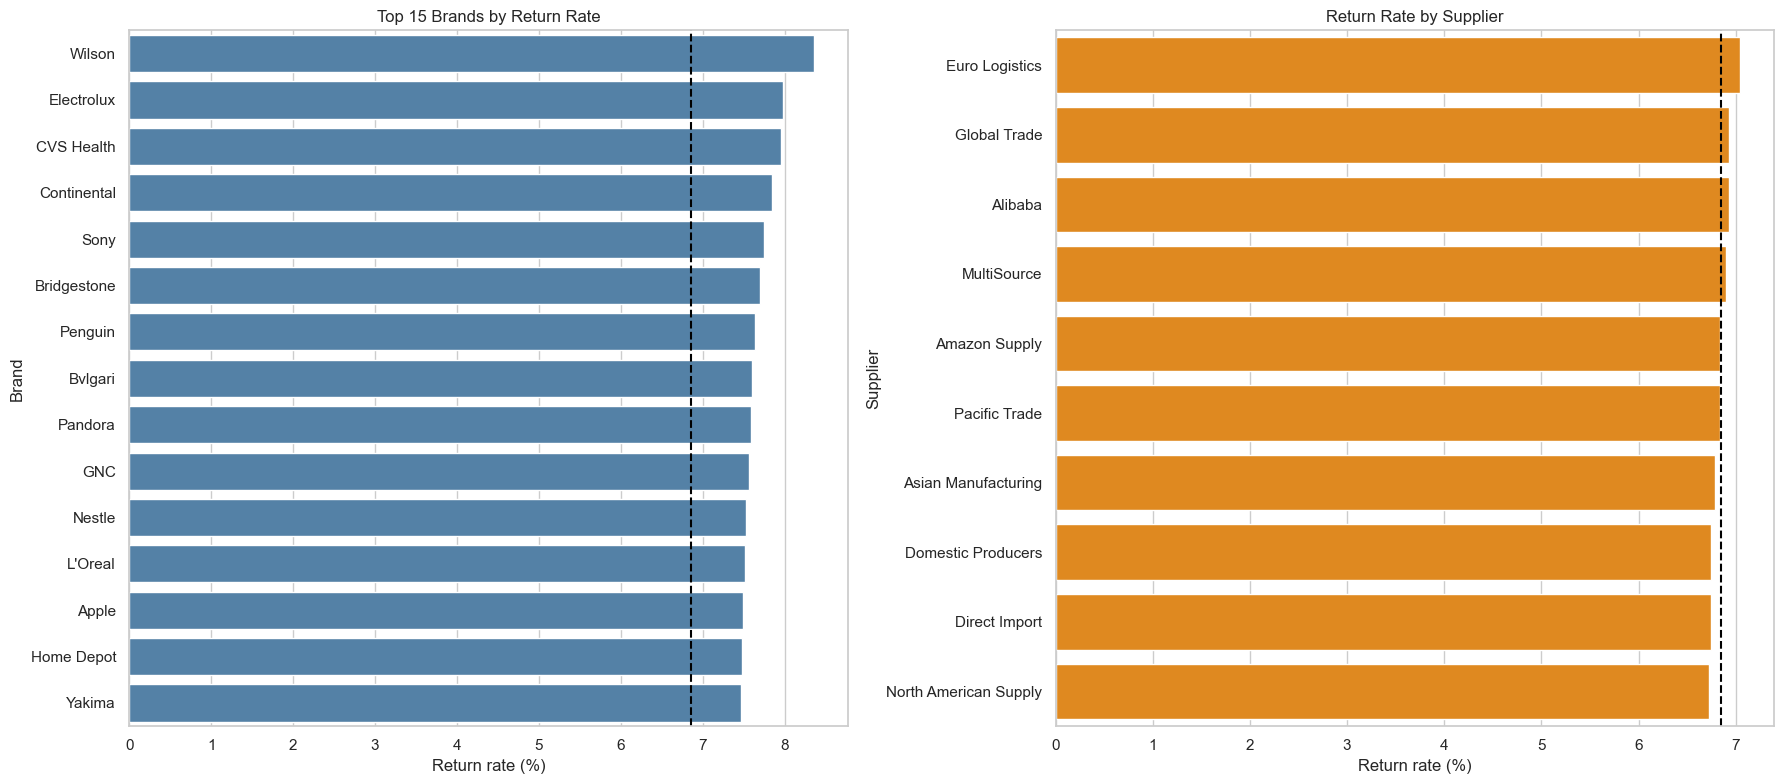

In [10]:
brand_summary = create_product_return_summary(
    product_order_df,
    "brand",
    min_orders=100
)

supplier_summary = create_product_return_summary(
    product_order_df,
    "supplier",
    min_orders=100
)

display(brand_summary.head(15))
display(supplier_summary)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(
    data=brand_summary.head(15),
    y="brand",
    x="return_rate_percent",
    color="steelblue",
    ax=axes[0]
)
axes[0].axvline(overall_return_rate, linestyle="--", color="black")
axes[0].set_title("Top 15 Brands by Return Rate")
axes[0].set_xlabel("Return rate (%)")
axes[0].set_ylabel("Brand")

sns.barplot(
    data=supplier_summary,
    y="supplier",
    x="return_rate_percent",
    color="darkorange",
    ax=axes[1]
)
axes[1].axvline(overall_return_rate, linestyle="--", color="black")
axes[1].set_title("Return Rate by Supplier")
axes[1].set_xlabel("Return rate (%)")
axes[1].set_ylabel("Supplier")

plt.tight_layout()
plt.show()

# Price, Discount, Quantity, And Rating Analysis

In [11]:
analysis_numeric_df = product_order_df.copy()

analysis_numeric_df["price_band"] = pd.qcut(
    analysis_numeric_df["catalog_unit_price"],
    q=4,
    duplicates="drop"
)

analysis_numeric_df["discount_band"] = pd.qcut(
    analysis_numeric_df["average_discount_percentage"],
    q=4,
    duplicates="drop"
)

analysis_numeric_df["quantity_band"] = pd.qcut(
    analysis_numeric_df["total_quantity"],
    q=4,
    duplicates="drop"
)

analysis_numeric_df["rating_band"] = pd.qcut(
    analysis_numeric_df["product_rating"],
    q=4,
    duplicates="drop"
)

price_summary = create_product_return_summary(
    analysis_numeric_df, "price_band"
)

discount_summary = create_product_return_summary(
    analysis_numeric_df, "discount_band"
)

quantity_summary = create_product_return_summary(
    analysis_numeric_df, "quantity_band"
)

rating_summary = create_product_return_summary(
    analysis_numeric_df, "rating_band"
)

display(price_summary)
display(discount_summary)
display(quantity_summary)
display(rating_summary)

C:\Users\Victus\AppData\Local\Temp\ipykernel_12116\2873163524.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_column, as_index=False)
C:\Users\Victus\AppData\Local\Temp\ipykernel_12116\2873163524.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_column, as_index=False)
C:\Users\Victus\AppData\Local\Temp\ipykernel_12116\2873163524.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .

,price_band,total_orders,returned_orders,return_rate,return_rate_percent
3,"(310.79, 1482.95]",72557,5034,0.07,6.94
2,"(164.97, 310.79]",72787,5016,0.07,6.89
1,"(74.36, 164.97]",72569,4934,0.07,6.80
0,"(6.308999999999999, 74.36]",72760,4927,0.07,6.77


,discount_band,total_orders,returned_orders,return_rate,return_rate_percent
0,"(-0.001, 0.0481]",55364,9462,0.17,17.09
2,"(0.124, 0.199]",68442,378,0.01,0.55
3,"(0.199, 0.6]",54555,298,0.01,0.55
1,"(0.0481, 0.124]",68069,370,0.01,0.54


,quantity_band,total_orders,returned_orders,return_rate,return_rate_percent
0,"(0.999, 2.0]",121844,8809,0.07,7.23
1,"(2.0, 3.0]",57806,3316,0.06,5.74
2,"(3.0, 8.0]",47558,2453,0.05,5.16


,rating_band,total_orders,returned_orders,return_rate,return_rate_percent
0,"(2.499, 3.1]",78980,5459,0.07,6.91
1,"(3.1, 3.7]",71731,4928,0.07,6.87
2,"(3.7, 4.3]",74984,5059,0.07,6.75
3,"(4.3, 4.9]",64112,4307,0.07,6.72


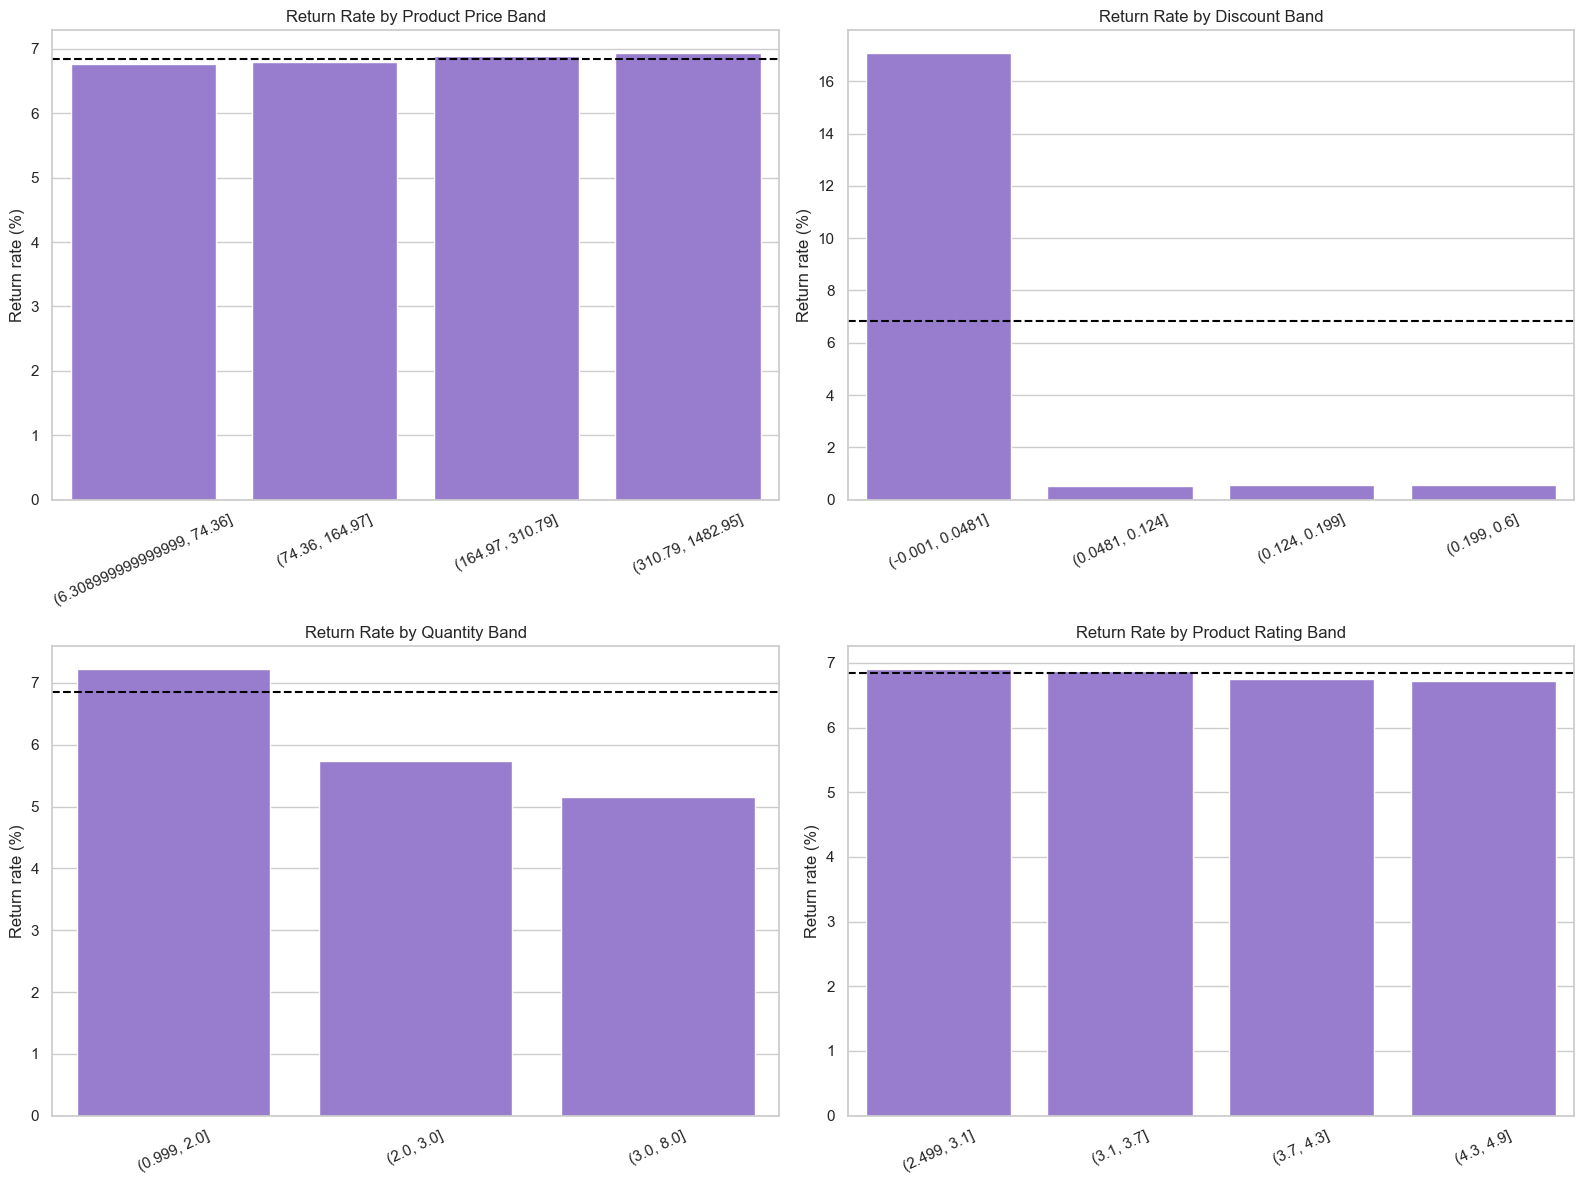

In [12]:
summaries = [
    (price_summary, "price_band", "Return Rate by Product Price Band"),
    (discount_summary, "discount_band", "Return Rate by Discount Band"),
    (quantity_summary, "quantity_band", "Return Rate by Quantity Band"),
    (rating_summary, "rating_band", "Return Rate by Product Rating Band")
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (summary, column, title) in zip(axes, summaries):
    sns.barplot(
        data=summary,
        x=column,
        y="return_rate_percent",
        color="mediumpurple",
        ax=ax
    )
    ax.axhline(overall_return_rate, linestyle="--", color="black")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Return rate (%)")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

# Products With Unusually High Return Rates

In [13]:
high_risk_product_summary = create_product_return_summary(
    product_order_df,
    "product_id",
    min_orders=50
)

product_details_df = (
    product_order_df[
        [
            "product_id",
            "product_name",
            "product_category",
            "product_subcategory",
            "brand",
            "supplier",
            "product_rating",
            "catalog_unit_price"
        ]
    ]
    .drop_duplicates(subset="product_id")
)

high_risk_products = (
    high_risk_product_summary
    .merge(
        product_details_df,
        on="product_id",
        how="left",
        validate="1:1"
    )
    .sort_values(
        ["return_rate_percent", "total_orders"],
        ascending=[False, False]
    )
)

display(
    high_risk_products[
        [
            "product_id",
            "product_name",
            "product_category",
            "brand",
            "total_orders",
            "returned_orders",
            "return_rate_percent",
            "product_rating",
            "catalog_unit_price"
        ]
    ].head(20)
)

,product_id,product_name,product_category,brand,total_orders,returned_orders,return_rate_percent,product_rating,catalog_unit_price
0,PROD-000955,Tiffany Monitored leadingedge projection Rings,Jewelry,Tiffany,333,38,11.41,3.50,952.94
1,PROD-000779,Pfizer Multi-channeled zero-defect application...,Health & Wellness,Pfizer,323,36,11.15,3.60,47.63
2,PROD-000401,Spalding Function-based fresh-thinking budgeta...,Sports & Outdoors,Spalding,343,37,10.79,2.60,385.18
3,PROD-000923,Chicco Reduced mission-critical concept Furniture,Baby & Kids,Chicco,329,35,10.64,3.70,192.44
4,PROD-000706,Castrol Visionary regional capacity Cleaning,Automotive,Castrol,339,36,10.62,4.00,108.22
5,PROD-001078,Nestle Front-line directional framework Frozen...,Grocery,Nestle,320,34,10.62,2.60,62.74
6,PROD-000101,Electrolux Stand-alone bandwidth-monitored app...,Home Appliances,Electrolux,312,33,10.58,3.80,136.18
7,PROD-001099,PaperMate Vision-oriented executive implementa...,Office Supplies,PaperMate,336,35,10.42,4.10,290.74
8,PROD-000742,Garmin Distributed neutral superstructure Medi...,Health & Wellness,Garmin,319,33,10.34,3.60,83.94
9,PROD-000199,Calvin Klein Switchable bottom-line success Bags,Fashion,Calvin Klein,339,35,10.32,4.10,271.10
